# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [391]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from cross_sections import *
%matplotlib inline
pd.set_option('display.max_rows', None)

### Provide Directories

#### Provide the directory for transmission images

In [392]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp102"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [393]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\00_Raw_sorted\exp102\005_temp_01_p10_batch01\exp102_031_Spectra.txt"

#### Provide the directory for saving results

In [394]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\04_CS\exp102"

In [395]:
flight_path = 5.45

## Remove Casing 
read the directory and extract values from images

In [439]:
casing_dict = read_saved_dict (src_dir, proc_folder = ['003_temp_00_p20_batch03'])

Reading Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  2.49it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [440]:
avg_imgs = []
for key, value in casing_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_slice = 20, end_slice = 30)
    avg_imgs.append(img[0])

#### Select the Casing ROI
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [441]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
#ROIs_003_temp_00_p20_batch03  = [[58, 296, 234, 54]]
ROIs_003_temp_00_p20_batch03 = [[112, 288, 188, 70]]

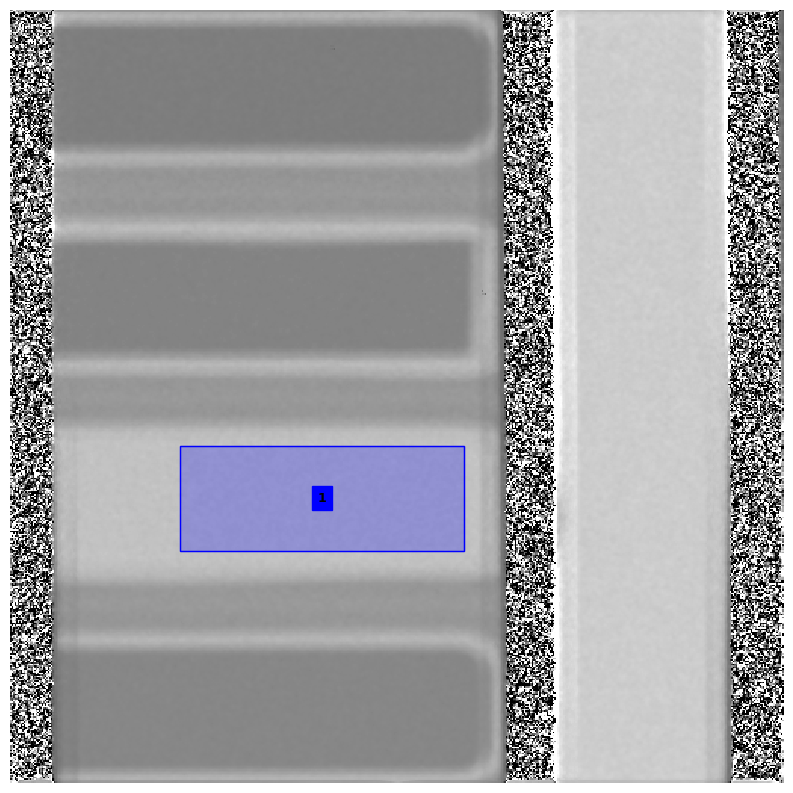

In [442]:
show_img(avg_imgs[0], dr = [(ROIs_003_temp_00_p20_batch03, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [443]:
rois_dict = {}
for name in casing_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

In [444]:
val_casing = get_roi_values (casing_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [445]:
val_casing

,Wavelength [Å],Values_003_temp_00_p20_batch03_roi_1
0,0.072588,0.918308
1,0.130658,0.917819
2,0.188728,0.909702
3,0.246798,0.908697
4,0.304869,0.910439
5,0.362939,0.915105
6,0.421009,0.914689
7,0.479079,0.907869
8,0.537150,0.912745
9,0.595220,0.906290


### Save the values of the casing for future references (Relative attenuation)

#val_casing = val_casing.loc[3:76, :]
#val_casing = val_casing.reset_index(drop=True)

#val_casing
HE_vals = val_casing.loc[15:30, val_casing.columns != 'Wavelength [Å]'].stack().mean()
LE_vals = val_casing.loc[70:85, val_casing.columns != 'Wavelength [Å]'].stack().mean()
casing_corr = [HE_vals,LE_vals]

casing_corr

%store casing_corr

## Process a single  experiment

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [446]:
stack_dict = read_saved_dict (src_dir, proc_folder = ['001_temp_00_p20_batch01'])

Reading Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  2.40it/s]


In [447]:
avg_imgs = []
for key, value in stack_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_slice = 20, end_slice = 30)
    avg_imgs.append(img[0])

In [448]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
ROIs_001_temp_00_p20_batch01  = [[73, 440, 212, 45], [77, 301, 212, 45],[76, 164, 209, 50], [199, 25, 87, 46]] #LP40,LP40,LP47,EC
#ROIs_046_temp_11_p51_batch02  = [[64, 438, 228, 47], [63, 298, 228, 47], [67, 163, 228, 47], [67, 23, 228, 47]]#EC-DMC11,ec-DEC11, EC-DEC37, DMC 
#ROIs_011_temp_02_p0_batch03  = [[58, 441, 234, 43], [52, 166, 231, 43], [58, 27, 231, 43]] #DEC,empty, PE, H2O

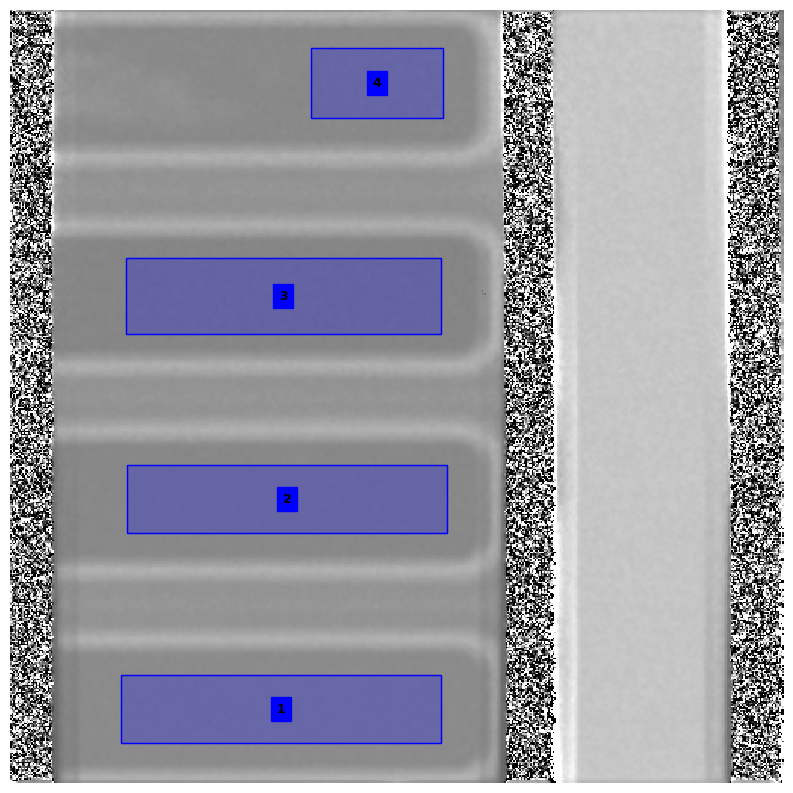

In [449]:
show_img(avg_imgs[0], dr = [(ROIs_001_temp_00_p20_batch01, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [450]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [451]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [452]:
#val_rois = table_val_rois.loc[3:76, :]
#val_rois = table_val_rois.reset_index(drop=True)

val_rois

,Wavelength [Å],Values_001_temp_00_p20_batch01_roi_1,Values_001_temp_00_p20_batch01_roi_2,Values_001_temp_00_p20_batch01_roi_3,Values_001_temp_00_p20_batch01_roi_4
0,0.072588,0.367992,0.353557,0.333140,0.355231
1,0.130658,0.373051,0.354548,0.338991,0.366817
2,0.188728,0.373713,0.358481,0.339440,0.361322
3,0.246798,0.383502,0.360447,0.342316,0.370147
4,0.304869,0.386511,0.363352,0.342961,0.367754
5,0.362939,0.387274,0.368121,0.346339,0.369590
6,0.421009,0.388853,0.370348,0.344840,0.367630
7,0.479079,0.395101,0.363086,0.350401,0.366603
8,0.537150,0.394059,0.370300,0.346504,0.367807
9,0.595220,0.400307,0.371625,0.346008,0.370666


### Remove the casing


In [453]:
trans_rois = divide_DF (val_rois, val_casing)

In [454]:
trans_rois

,Wavelength [Å],Values_001_temp_00_p20_batch01_roi_1,Values_001_temp_00_p20_batch01_roi_2,Values_001_temp_00_p20_batch01_roi_3,Values_001_temp_00_p20_batch01_roi_4
0,0.072588,0.400728,0.385009,0.362776,0.386832
1,0.130658,0.406454,0.386295,0.369345,0.399662
2,0.188728,0.410807,0.394064,0.373133,0.397187
3,0.246798,0.422035,0.396664,0.376711,0.407339
4,0.304869,0.424532,0.399095,0.376698,0.403931
5,0.362939,0.423202,0.402272,0.378469,0.403878
6,0.421009,0.425121,0.404890,0.377002,0.401918
7,0.479079,0.435196,0.399932,0.385960,0.403806
8,0.537150,0.431729,0.405700,0.379628,0.402968
9,0.595220,0.441699,0.410051,0.381785,0.408993


### H cross section parameters

In [455]:
thickness = 0.3
h2o = {'abbv': 'H2O','composition' : {'H':2.0, 'O':1.0},'density':0.997, 'thickness': thickness}
ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dmc_11w = {'abbv': 'EC_DMC (1:1w)','molecules' : [ec,0.447511501,dmc,0.552488499], 'density':1.2335, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
ec_dec_37w = {'abbv': 'EC_DEC (3:7w)','molecules' : [ec,0.240305619,dec,0.759694381], 'density':1.0705, 'thickness': thickness}
lp30 = {'abbv': 'LP30','molecules' : [ec, 0.446003162,dmc, 0.446003162, lipf6, 0.107993676], 'density':1.2795, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}
lp47 = {'abbv': 'LP47','molecules' : [ec, 0.218207723,dec, 0.689834809, lipf6 ,0.091957467], 'density':1.1685, 'thickness': thickness}
#ec_dec_sol = {'abbv': 'EC_DEC (sol)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
pe = {'abbv': 'PE', 'composition' : {'C':1.0, 'H':2.0},'density':0.92, 'thickness': 0.22}

## exp1000 -> LP30


In [456]:
compounds_dict=[lp30,lp40,lp47,ec]
#compounds_dict=[ec_dmc_11v,ec_dec_11v,ec_dec_37w, dmc]
#compounds_dict = [dec, pe, h2o]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [457]:
requested_cs = ['h_cs']
cs_table = get_cross_sections (trans_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')

In [458]:
cs_table

,Wavelength [Å],CS_H_in_LP30_Values_001_temp_00_p20_batch01_roi_1,CS_H_in_LP40_Values_001_temp_00_p20_batch01_roi_2,CS_H_in_LP47_Values_001_temp_00_p20_batch01_roi_3,CS_H_in_EC_Values_001_temp_00_p20_batch01_roi_4
0,0.072588,80.532619,77.423269,75.602940,81.272565
1,0.130658,79.190908,77.134245,74.184453,78.260414
2,0.188728,78.183340,75.407327,73.377772,78.834030
3,0.246798,75.633296,74.837093,72.623389,76.504089
4,0.304869,75.066190,74.298894,72.619294,77.278847
5,0.362939,75.318409,73.571804,72.216603,77.287936
6,0.421009,74.845436,72.969249,72.491291,77.733486
7,0.479079,72.584727,73.997358,70.602238,77.296909
8,0.537150,73.295199,72.714966,71.876877,77.484194
9,0.595220,71.089747,71.748581,71.395651,76.109279


In [ ]:
cs_ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI"
cs_ref_data = pd.read_csv (cs_ref_dir + '\cs_ref_IMAT20.txt',sep='\t')
cs_ref_data = cs_ref_data.loc[0:93, ['orig wvl','orig cs LP30', 'orig cs PE']]
cs_ref_data = cs_ref_data.reset_index(drop=True)
cs_ref_data

In [ ]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table.plot.scatter(x='Wavelength [Å]', y=['CS_H_in_PE_Values_003_temp_00_p20_batch03_roi_2'])
cs_ref_data.plot(ax = ax, x='orig wvl', y=['orig cs PE'], 
                 grid = True, fontsize = 12, kind = 'scatter', color = 'r')

plt.suptitle('H CS in BOA experiments', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("H cross-section [barns]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

## Option to make the relative attenuation images 


In [ ]:
HE_n_LE = ([15,30],[70,85])

trans_imgs_dict = read_saved_dict (src_dir, proc_folder = [])

In [ ]:
proc_folder1 = [key for key in trans_imgs_dict.keys() if 'batch01' in key]
proc_folder2 = [key for key in trans_imgs_dict.keys() if 'batch02' in key]
proc_folder3 = [key for key in trans_imgs_dict.keys() if 'batch03' in key]

In [ ]:
res_stack = get_relative_att_stack (trans_imgs_dict, dst_dir, HE_n_LE, proc_folder = proc_folder1, save=False)